In [1]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, VelocityState
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution, BidHStarSearch, calculate_path_smoothness
from hexplot import plot_hex_grid_2

#### Map parameters

In [2]:
center = HexCoord(0,0)
start = HexCoord(5,0)
goal = HexCoord(0,-5)
radius = 8
hex_size = 1
seed = 0
num_obs = 10

#### Agent parameters

In [3]:
a_max = 3 # acceleration ability
a_min = 1 # deceleration ability
a_lat = 7 # maximum lateral g-force allowed by the agent

#### Build obstacle set

In [4]:
obstacles = set(
    build_obstacle_map(
        center=center,
        radius=radius,
        seed=seed,
        exclude=[start, goal],
        types=[
            ("random_n", {"n": 10})
        ],
    ).keys()
)
print(obstacles)

{HexCoord(q=-3, r=-2), HexCoord(q=-3, r=7), HexCoord(q=-2, r=-6), HexCoord(q=1, r=0), HexCoord(q=0, r=2), HexCoord(q=-6, r=6), HexCoord(q=2, r=2), HexCoord(q=4, r=-1), HexCoord(q=8, r=-8), HexCoord(q=3, r=-8)}


#### Initialize problem class

In [5]:
hex_grid = HexGrid(hex_size, obstacles)

start_v = VelocityState(0, None) # 0 speed, unspecified direction (allows expansion in any direction at root)
goal_v = VelocityState(0, None) # matches any direction as long as location matches. 

problem = HStarProblem(
    hex_grid,
    start,
    goal,
    a_max,  
    a_min,  
    start_v = start_v,
    goal_v = goal_v,
    collision_radius = 0,
    heuristic = h_cost_travel_time,
    n_step = 20,
    
)

<Axes: >

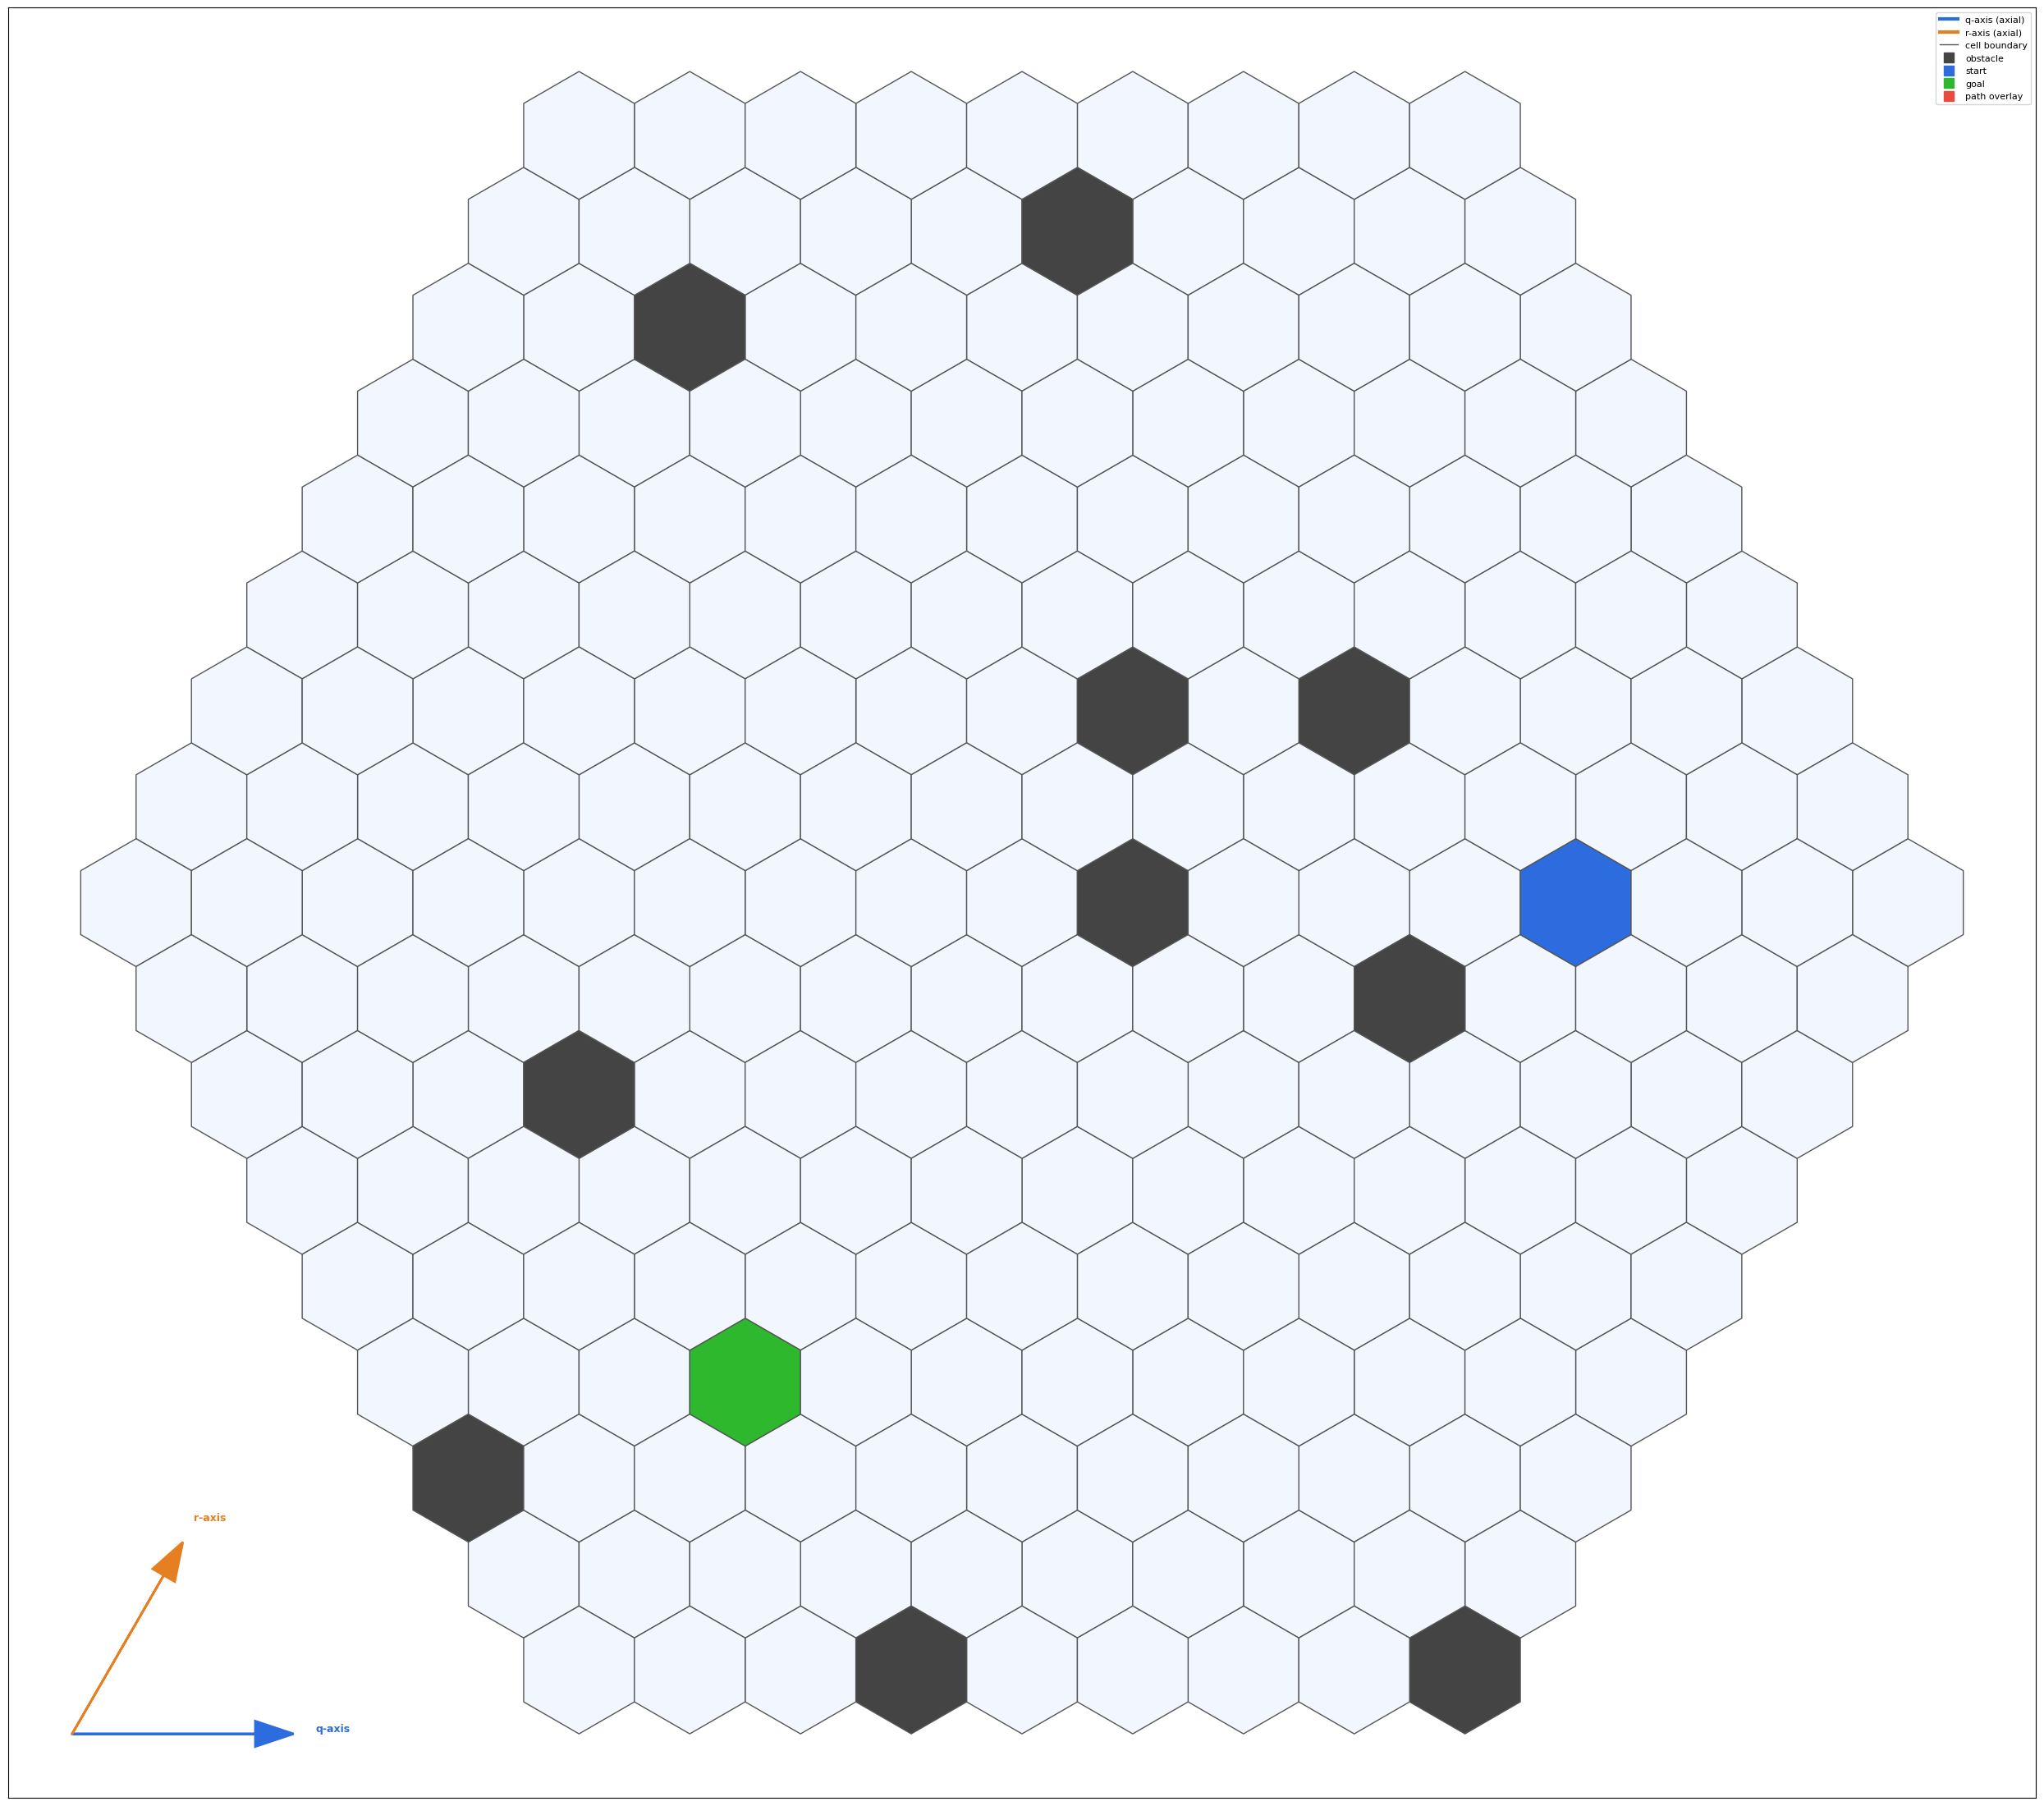

In [6]:
plot_hex_grid_2(
    obstacles,
    start,
    center,
    radius,
    goal=goal,
    figsize=(25, 25),
    show_coords=False,
    linewidth=1,
    draw_axes=True,
    show_axis_legend=True,
)

#### Regular H* search example

In [7]:
hs = BidHStarSearch(
    problem = problem,
    bidirectional = False,
)
fsolution = hs.search()
f_soln_path = construct_full_solution(fsolution)

In [8]:
hs.get_benchmarks()

{'nodes_reached': 2252,
 'nodes_expanded': 9,
 'search_time': 0.45630335807800293,
 'solution_cost': 8.903808006793522,
 'solution_length': 4,
 'open_set_sizes': [1, 578, 791, 992, 1191, 1403, 1618, 1833, 2033, 2232],
 'closed_set_sizes': [1, 579, 793, 995, 1195, 1408, 1624, 1840, 2041, 2241],
 'integrated_curvature_squared': 0.12113714537696874,
 'total_absolute_curvature': 0.8910206802181005,
 'heading_changes': 1,
 'minimum_turning_radius': 7.794870107962032}

In [9]:

if fsolution is not None:
    solution_locations = [node.location for node in fsolution]

    smoothness = calculate_path_smoothness(
        solution_locations,
        hex_size=problem.grid.hex_size,
    )

    print(smoothness)

PathSmoothnessMetrics(integrated_curvature_squared=0.12113714537696874, total_absolute_curvature=0.8910206802181005, heading_changes=1, minimum_turning_radius=7.794870107962032)


<Axes: >

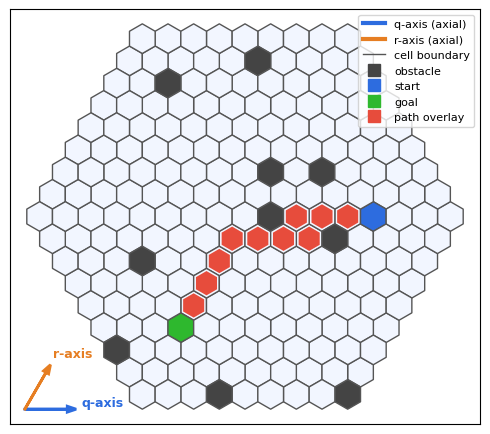

In [10]:
plot_hex_grid_2(
    obstacles,
    start,
    center,
    radius,
    goal=goal,
    figsize=(5, 5),
    show_coords=False,
    linewidth=1,
    path = f_soln_path,
    draw_axes=True,
    show_axis_legend=True,
)

#### Bidirectional H* search example

In [11]:
bihs = BidHStarSearch(
    problem = problem,
    join_tolerance=50
)
bidsolution = bihs.search()
bid_soln_path = construct_full_solution(bidsolution)

In [12]:
bidsolution

[Node(location=HexCoord(q=5, r=0), velocity=VelocityState(magnitude=0, direction=None), parent=None, step_distance=None, g_cost=0.0, h_cost=3.398088489694245, f_cost=3.398088489694245),
 Node(location=HexCoord(q=4, r=-5), velocity=VelocityState(magnitude=3.7224194364083982, direction=277), parent=Node(location=HexCoord(q=5, r=0), velocity=VelocityState(magnitude=0, direction=None), parent=None, step_distance=None, g_cost=0.0, h_cost=3.398088489694245, f_cost=3.398088489694245), step_distance=9.643650760992955, g_cost=5.181388570385124, h_cost=1.2408064788027995, f_cost=6.422195049187923),
 Node(location=HexCoord(q=2, r=-5), velocity=VelocityState(magnitude=2.6321480259049848, direction=384), parent=Node(location=HexCoord(q=4, r=-5), velocity=VelocityState(magnitude=3.7224194364083982, direction=277), parent=Node(location=HexCoord(q=5, r=0), velocity=VelocityState(magnitude=0, direction=None), parent=None, step_distance=None, g_cost=0.0, h_cost=3.398088489694245, f_cost=3.39808848969424

In [13]:
bihs.get_benchmarks()

{'nodes_reached': 1373,
 'nodes_expanded': 3,
 'forward_nodes_reached': 792,
 'reverse_nodes_reached': 581,
 'forward_nodes_expanded': 2,
 'reverse_nodes_expanded': 1,
 'search_time': 0.21147656440734863,
 'solution_cost': 8.903808006793522,
 'solution_length': 4,
 'solution_depth': 3,
 'effective_branching_factor': 1.0,
 'open_set_sizes': [2, 579, 1159],
 'closed_set_sizes': [2, 580, 1161],
 'forward_open_set_sizes': [1, 578],
 'reverse_open_set_sizes': [1],
 'forward_closed_set_sizes': [1, 579],
 'reverse_closed_set_sizes': [1],
 'iterations': 3,
 'join_checks': 0,
 'join_found': True,
 'meeting_location': HexCoord(q=2, r=-5),
 'progress_snapshots': [],
 'integrated_curvature_squared': 0.12113714537696875,
 'total_absolute_curvature': 0.8910206802181005,
 'heading_changes': 1,
 'minimum_turning_radius': 7.794870107962027}

In [14]:
problem.DIRECTIONS_INFO[HexCoord(q=1, r=0)]

DirectionInfo(s=1.7320508075688772, blockers={HexCoord(q=1, r=0), HexCoord(q=0, r=0)})

In [15]:
import math
import pandas as pd


def axial_angle_degrees(coord):
    """
    Return the geometric angle of an axial HexCoord displacement.

    Convention:
        HexCoord(1, 0)  ->   0 degrees
        HexCoord(0, 1)  ->  60 degrees
        HexCoord(-1, 1) -> 120 degrees
        HexCoord(-1, 0) -> 180 degrees
        HexCoord(0, -1) -> 240 degrees
        HexCoord(1, -1) -> 300 degrees
    """
    q = coord.q
    r = coord.r

    # Axial coordinate to Cartesian displacement
    x = q + (r / 2)
    y = (math.sqrt(3) / 2) * r

    # Normalize to [0, 360)
    return math.degrees(math.atan2(y, x)) % 360


def axial_hex_distance_from_origin(coord):
    """
    Return the hex-grid distance of an axial displacement from (0, 0).

    Axial coordinates (q, r) correspond to cube coordinates:

        x = q
        z = r
        y = -q - r

    Therefore:

        distance = max(abs(q), abs(r), abs(q + r))
    """
    return max(
        abs(coord.q),
        abs(coord.r),
        abs(coord.q + coord.r),
    )


rows = []

for direction, info in problem.DIRECTIONS_INFO.items():
    rows.append({
        "direction": str(direction),
        "q": direction.q,
        "r": direction.r,
        "n_step": axial_hex_distance_from_origin(direction),
        "angle_degrees": axial_angle_degrees(direction),
        "s": info.s,
        "blockers": ", ".join(
            sorted(str(blocker) for blocker in info.blockers)
        ),
    })


df = pd.DataFrame(rows)

# Optional: order by n_step and then geometric angle.
df = (
    df
    .sort_values(
        by=["n_step", "angle_degrees"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)


df.to_excel(
    "directions_info.xlsx",
    index=False,
    engine="openpyxl",
)


In [16]:
dir(problem)

['DIRECTIONS',
 'DIRECTIONS_INFO',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'a_max',
 'a_min',
 'action_cost',
 'actions',
 'ay_window_ms',
 'backtrack',
 'backtrack_transition_function',
 'calculate_turning_radius',
 'candidate_dir_indices',
 'collision_clear',
 'collision_radius',
 'collision_radius_map',
 'constrain_velocity',
 'enforce_goal_velocity',
 'epsilon',
 'expand_counter',
 'generate_collision_radius_map',
 'get_available_hexes_in_dir',
 'goal',
 'goal_v',
 'grid',
 'heuristic',
 'heuristic_consistent_flag',
 'is_goal',
 'is_goal_dir',
 'is_goal_loc',
 'jps_horizon',
 'n_step',
 'result',
 'reverse',
 'reverse_dir_idx',
 'search_direction',
 'start'

<Axes: title={'center': 'n=1 Straight (0°)'}>

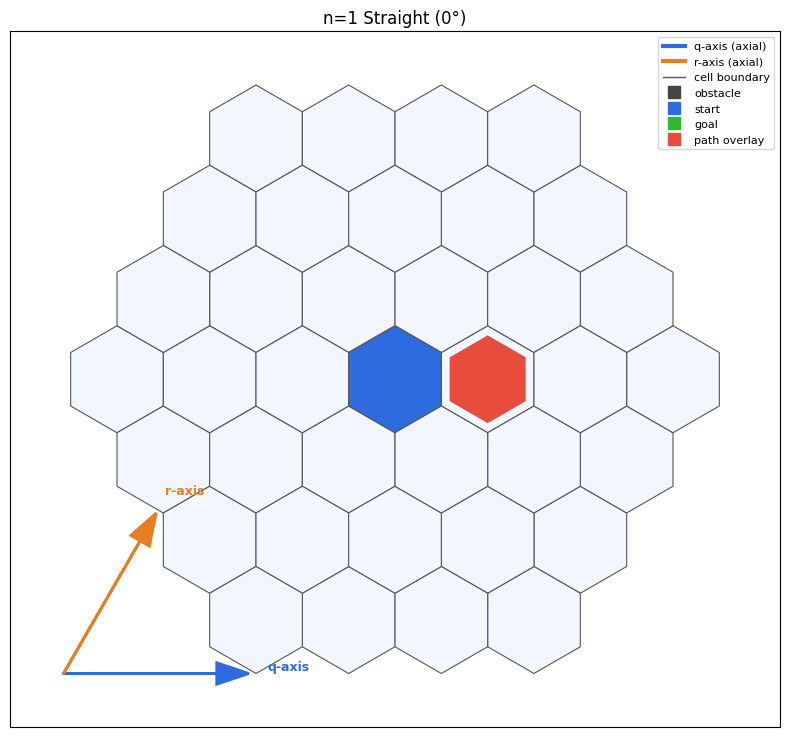

In [17]:
start = HexCoord(0, 0)
E  = HexCoord( 1,  0)
NE = HexCoord( 1, -1)
NW = HexCoord( 0, -1)
W  = HexCoord(-1,  0)
SW = HexCoord(-1,  1)
SE = HexCoord( 0,  1)
plot_hex_grid_2(
    obstacles=[],
    start=HexCoord(0, 0),
    center=HexCoord(0, 0),
    radius=3,
    path=[
        HexCoord(0, 0),
        HexCoord(1, 0),
    ],
    plt_title="n=1 Straight (0°)"
)


<Axes: title={'center': 'n=1 Smooth Turn (60°)'}>

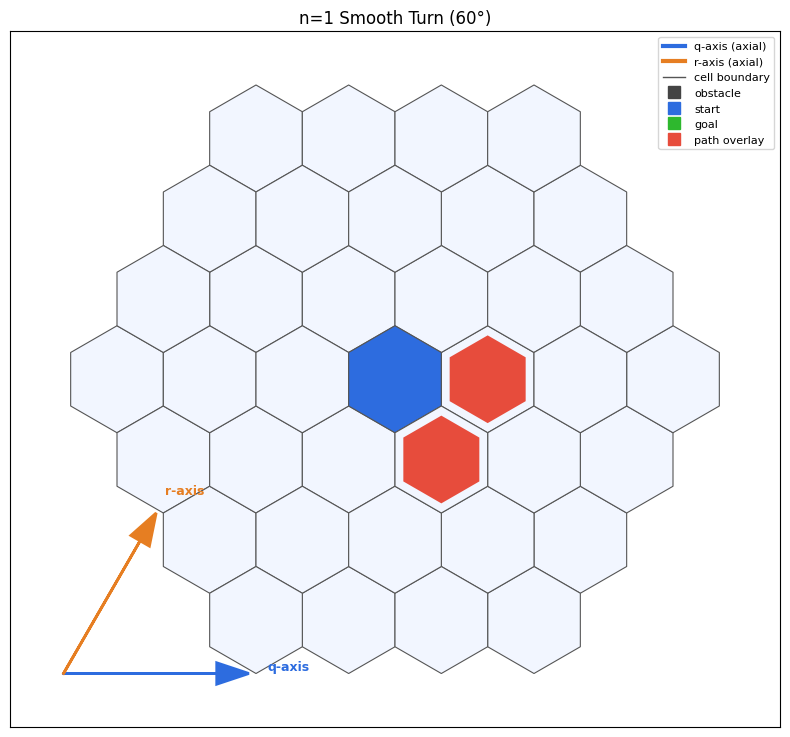

In [18]:
plot_hex_grid_2(
    obstacles=[],
    start=HexCoord(0, 0),
    center=HexCoord(0, 0),
    radius=3,
    path=[
        HexCoord(0, 0),
        HexCoord(1, 0),
        HexCoord(1, -1),
    ],
    plt_title="n=1 Smooth Turn (60°)"
)


<Axes: >

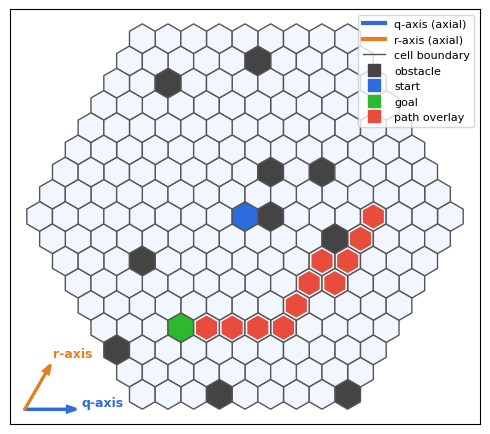

In [19]:
plot_hex_grid_2(
    obstacles,
    start,
    center,
    radius,
    goal=goal,
    figsize=(5, 5),
    show_coords=False,
    linewidth=1,
    path = bid_soln_path,
    draw_axes=True,
    show_axis_legend=True,
)